# Understanding `__init__` in Classes




### What is `__init__`?

`__init__` is a **special method** (also called a "magic method" or "dunder method" - double underscore) that:
- Gets called **automatically** when you create a new object/instance
- **Initializes** the object with starting values
- Is like the "constructor" in other programming languages (Java, C++)
- The name means "initialize"

### Why Do We Need It?

Imagine you want to create 100 different stacks. Each stack needs its own separate `items` list. `__init__` sets up that individual storage for each stack.

Without `__init__`, all stacks would share the SAME list (disaster!).

### Visual Difference

```
WITHOUT __init__ (WRONG):
┌─────────────────┐
│  ClassBad obj   │
│  items → ───────┼──┐
└─────────────────┘  │
┌─────────────────┐  │
│  ClassBad obj   │  │
│  items → ───────┼──┤
└─────────────────┘  │
                     ▼
              Same list [1, 2]
              (Shared!)

WITH __init__ (CORRECT):
┌─────────────────┐
│  ClassGood obj  │
│  items → ───────┼──────┐
└─────────────────┘      │
┌─────────────────┐      │
│  ClassGood obj  │      │
│  items → ───────┼──┐   │
└─────────────────┘  │   │
                     │   ▼
              [1]    [2]
              (Separate!)

### Syntax

```python
class ClassName:
    def __init__(self, parameters):
        # Initialize instance variables here
        self.variable1 = initial_value
        self.variable2 = parameter
```

### Key Points

- `self` = reference to the current object being created
- Everything after `self` are optional parameters you pass when creating the object
- Code inside `__init__` runs **ONCE** automatically when object is created
- Variables created with `self.` are **instance variables** (belong to that specific object)

### When Does `__init__` Get Called?

```python

# When you write this:
my_object = ClassName()

# Python automatically does this:
# 1. Create a new empty object
# 2. Call __init__() on that object
# 3. Return the object

# So __init__ runs automatically!
```

In [1]:
print("=== Understanding __init__ ===\n")

# Example 1: Simple class without __init__ (problematic)
print("Example 1: Class WITHOUT __init__ (Problem)")
print("-" * 50)

class PersonBad:
    pass

person1 = PersonBad()
person2 = PersonBad()

# We can manually set attributes, but they're not automatic
person1.name = "Alice"
person2.name = "Bob"

print(f"person1.name = {person1.name}")
print(f"person2.name = {person2.name}")

# Problem: If we forget to set an attribute, it crashes
try:
    print(f"person1.age = {person1.age}")
except AttributeError as e:
    print(f"ERROR: {e}")
    print("We forgot to set person1.age manually!")

print("\n\n" + "=" * 50)
print("Example 2: Class WITH __init__ (Solution)")
print("-" * 50 + "\n")

class PersonGood:
    def __init__(self, name, age):
        """Initialize a person with name and age"""
        print(f"  Creating person: {name}, age {age}")
        self.name = name
        self.age = age
        self.email = f"{name.lower()}@example.com"

# When we create objects, __init__ runs automatically
print("Creating person1:")
person1 = PersonGood("Alice", 25)

print("\nCreating person2:")
person2 = PersonGood("Bob", 30)

print("\nNow attributes are already set:")
print(f"person1.name = {person1.name}")
print(f"person1.age = {person1.age}")
print(f"person1.email = {person1.email}")

print(f"\nperson2.name = {person2.name}")
print(f"person2.age = {person2.age}")
print(f"person2.email = {person2.email}")

print("\n\nKey insight:")
print("- Each object has its OWN name, age, email")
print("- __init__ set them up automatically")
print("- No need to manually set attributes after creation")


print("\n\n" + "=" * 50)
print("Example 3: The 'self' Parameter Explained")
print("-" * 50 + "\n")

class Dog:
    def __init__(self, name, breed):
        # 'self' refers to THIS specific dog object
        print(f"Creating a dog (self = {self})")
        self.name = name
        self.breed = breed
    
    def bark(self):
        # 'self' is how we access this dog's attributes
        print(f"{self.name} the {self.breed} says: Woof!")

print("Creating two dogs:")
dog1 = Dog("Buddy", "Golden Retriever")
print(f"  dog1 object id: {id(dog1)}\n")

dog2 = Dog("Max", "Bulldog")
print(f"  dog2 object id: {id(dog2)}\n")

print("Each dog is a different object with different attributes:")
dog1.bark()
dog2.bark()

print(f"\ndog1 is at memory address: {id(dog1)}")
print(f"dog2 is at memory address: {id(dog2)}")
print(f"They are DIFFERENT objects, each with their own 'self'")


=== Understanding __init__ ===

Example 1: Class WITHOUT __init__ (Problem)
--------------------------------------------------
person1.name = Alice
person2.name = Bob
ERROR: 'PersonBad' object has no attribute 'age'
We forgot to set person1.age manually!


Example 2: Class WITH __init__ (Solution)
--------------------------------------------------

Creating person1:
  Creating person: Alice, age 25

Creating person2:
  Creating person: Bob, age 30

Now attributes are already set:
person1.name = Alice
person1.age = 25
person1.email = alice@example.com

person2.name = Bob
person2.age = 30
person2.email = bob@example.com


Key insight:
- Each object has its OWN name, age, email
- __init__ set them up automatically
- No need to manually set attributes after creation


Example 3: The 'self' Parameter Explained
--------------------------------------------------

Creating two dogs:
Creating a dog (self = <__main__.Dog object at 0x106a2d6a0>)
  dog1 object id: 4406302368

Creating a dog (self 

## Summary: What is `__init__` and Why You Need It

### Quick Answer

`__init__` is a **special method that automatically runs when you create a new object**. It sets up the initial state (variables) for that object.

### The 5 Key Facts About `__init__`

| Fact | Explanation |
|------|-------------|
| **What** | Special method (constructor/initializer) |
| **When** | Runs automatically when you create an object |
| **Why** | Sets up each object's starting state |
| **How often** | Once per object (every time you create one) |
| **Without it** | All objects would share same data (disaster!) |

### Basic Structure

```python
class ClassName:
    def __init__(self, param1, param2):
        self.attribute1 = param1
        self.attribute2 = param2
        # Any initialization code here
```

### Three Types of Variables in Classes

```python
class Example:
    class_var = "shared"          # Shared by ALL instances
    
    def __init__(self, value):
        self.instance_var = value # Each object gets its own
        local_var = "temporary"   # Disappears after __init__

obj1 = Example("data1")
obj2 = Example("data2")

print(obj1.instance_var)  # "data1" - separate
print(obj2.instance_var)  # "data2" - separate
print(obj1.class_var)     # "shared" - same for both
print(obj2.class_var)     # "shared" - same for both
```

### Common Mistakes to Avoid

```python
# WRONG: Sharing storage (all objects use same list)
class BadStack:
    items = []

# RIGHT: Each object gets own storage
class GoodStack:
    def __init__(self):
        self.items = []

# WRONG: Using local variable (lost after __init__)
class BadCounter:
    def __init__(self):
        count = 0  # Disappears!

# RIGHT: Using instance variable
class GoodCounter:
    def __init__(self):
        self.count = 0  # Persists!
```

### Real-World Analogy

Think of `__init__` as a **blueprint setup**:
- Without `__init__`: You buy a car and try to set up everything yourself (fuel, oil, tires)
- With `__init__`: The car comes pre-configured from the factory

### Practice Rule

- **Always use `__init__`** when creating classes
- It's the professional, safe way to initialize objects
- It prevents subtle bugs from shared data

# __str__

__str__ is a special Python method that controls how your object appears when you print it.

It's called automatically whenever you:

- Print an object: print(my_object)
- Convert to string: str(my_object)
- Display in interactive mode

In [3]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

# WITHOUT __str__:
person = Person("Alice", 25)
print(person)  # Output: <__main__.Person object at 0x7f8b8c0d5f40>
               # Ugly! Just shows memory address


In [4]:
# WITH __str__:
class PersonGood:
    def __init__(self, name, age):
        self.name = name
        self.age = age
    
    def __str__(self):
        return f"{self.name} is {self.age} years old"

person = PersonGood("Alice", 25)
print(person)  # Output: Alice is 25 years old
               # Much better!

Alice is 25 years old


# if __name__ == "__main__":

## Understanding `if __name__ == "__main__":`

`if __name__ == "__main__":` is a **guard that checks if your script is running directly or being imported**. Code inside this block only runs when you execute the script directly, not when it's imported as a module.

### Quick Explanation

```python
# Example script: my_script.py

def say_hello():
    print("Hello!")

if __name__ == "__main__":
    print("Script is running directly")
    say_hello()
else:
    print("Script is being imported")
```

### Scenario 1: Running Directly

```bash
python my_script.py
```

Output:
```
Script is running directly
Hello!
```

### Scenario 2: Importing as Module

```python
import my_script

my_script.say_hello()
```

Output:
```
Script is being imported
Hello!
```

### How It Works

| Situation | `__name__` Value | Code Executes? |
|-----------|------------------|---|
| Running script directly | `"__main__"` | YES |
| Importing as module | Module name (e.g., `"my_script"`) | NO |

### Real-World Example

```python
# calculator.py

def add(a, b):
    return a + b

def multiply(a, b):
    return a * b

# Only run these tests when script executes directly
if __name__ == "__main__":
    print("Testing calculator:")
    print(f"2 + 3 = {add(2, 3)}")
    print(f"4 * 5 = {multiply(4, 5)}")
```

**If you run it directly:**

```bash
python calculator.py
# Output: Testing calculator...
```

**If you import it:**

```python
from calculator import add
print(add(10, 20))  # Works, but doesn't print test output
# Output: 30
```

### Why Use It?

- Reusable code: Functions work when imported, without running test code
- Test locally: Test your code when running directly
- Clean modules: Import only what you need, no unwanted side effects
- Best practice: Professional Python standard

### Common Pattern

```python
def main():
    """Main function - runs when script executes directly"""
    print("Running main program")
    # Your code here

if __name__ == "__main__":
    main()
```

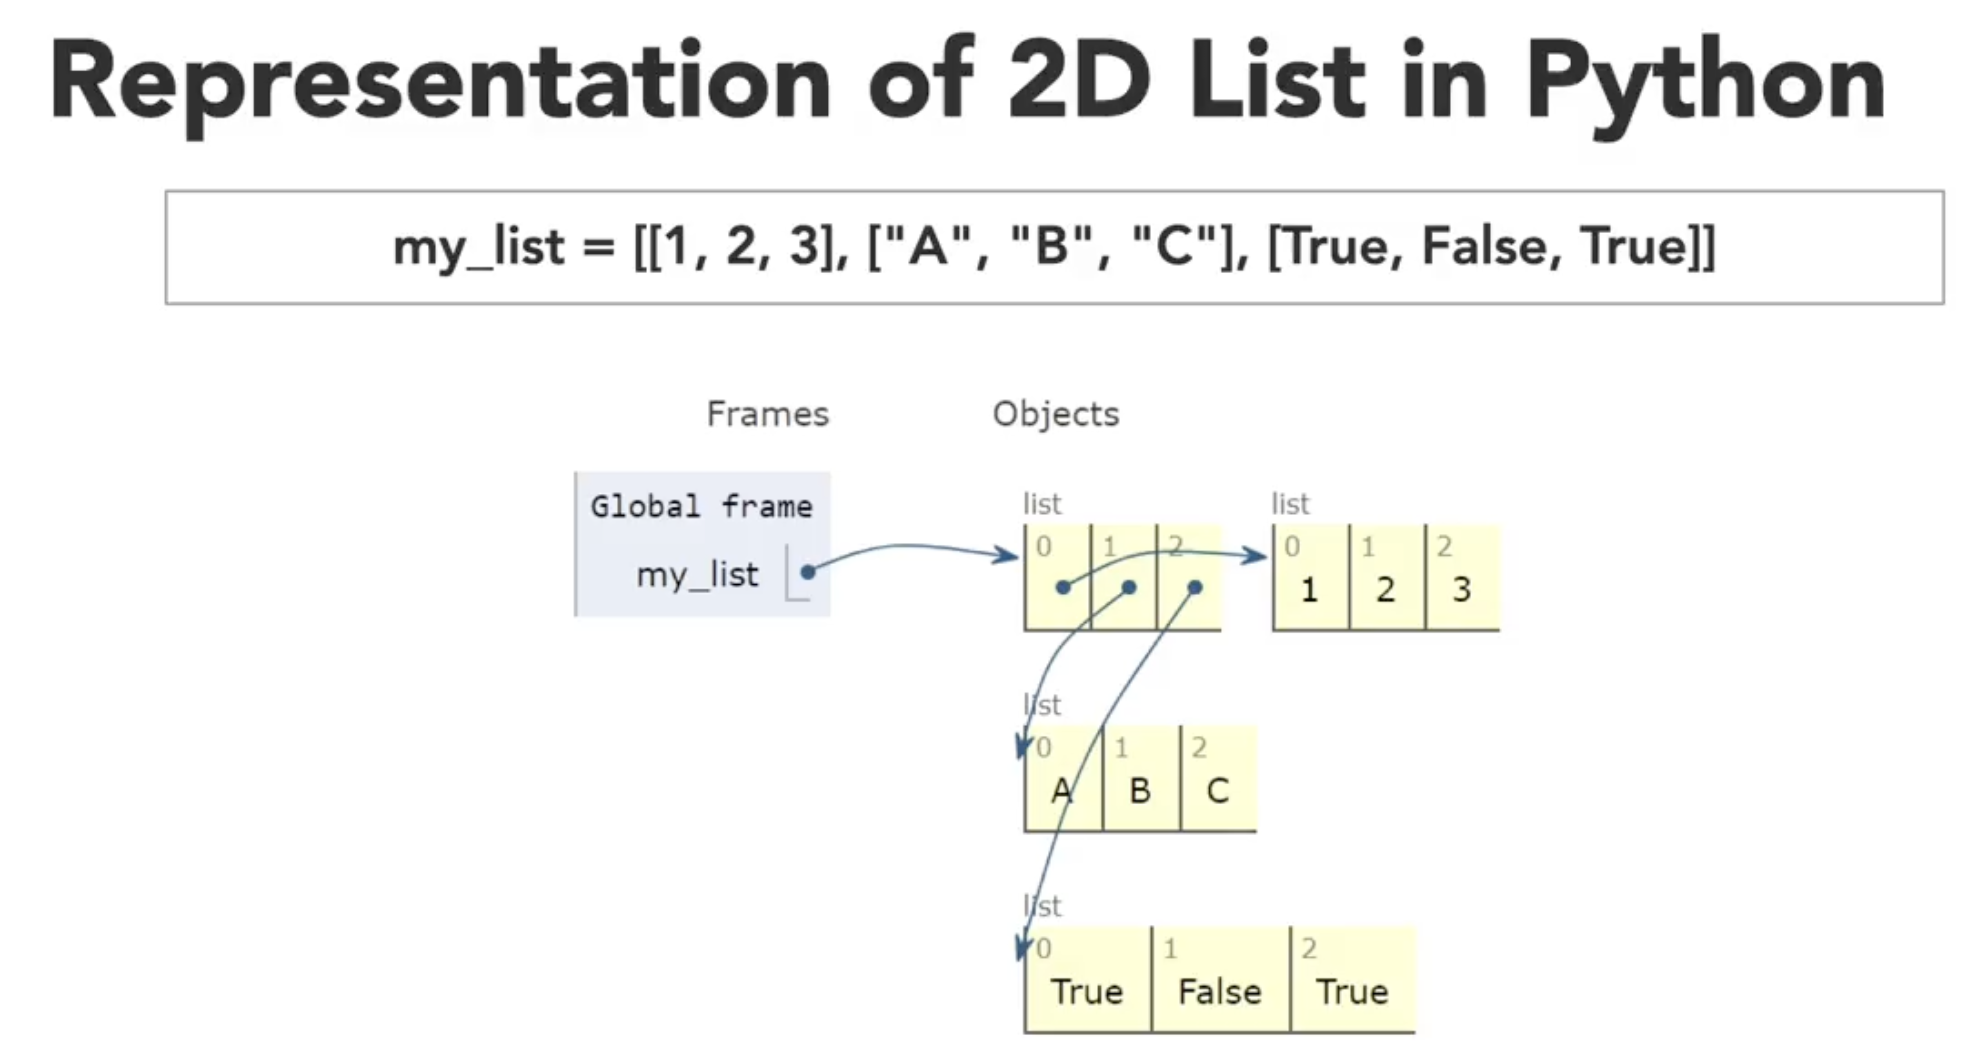

## Understanding 2D Lists in Python

This image explains **how 2D lists work in Python** - they are actually **lists of lists**, not a single 2D grid in memory.

### How It Works

**Main list structure:**
- `my_list` contains 3 elements at indices 0, 1, and 2
- Each element is a **reference** that points to a separate list object in memory

**Nested lists:**
- Index 0 → `[1, 2, 3]` (numbers)
- Index 1 → `["A", "B", "C"]` (strings)
- Index 2 → `[True, False, True]` (booleans)

### Key Insight

Unlike languages that have true 2D arrays, **Python stores 2D lists as references to separate list objects**. Each inner list is an independent object that the outer list points to.

### Accessing Elements

```python
my_list[0][0]  # Returns 1 (first inner list, first element)
my_list[1][2]  # Returns "C" (second inner list, third element)
my_list[2][1]  # Returns False (third inner list, second element)
```

# Slicing

Slicing is a powerful technique to extract portions of sequences (lists, strings, tuples). You already saw it in the `rotate` function!
## The Basic Syntax

```python
sequence[start:stop:step]

start  - Where to begin (inclusive) - Default: 0
stop   - Where to end (exclusive) - Default: end of sequence
step   - How many to skip - Default: 1
```

### Key Point: STOP is EXCLUSIVE

```python
arr = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
       0  1  2  3  4  5  6  7  8  9  (indices)

arr[2:5]  = [2, 3, 4]  ← Includes indices 2,3,4 but NOT 5 (stop is exclusive!)
```

In [5]:
print("=" * 80)
print("SLICING BASICS")
print("=" * 80 + "\n")

arr = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
print(f"Original array: {arr}\n")

print("1. START and STOP")
print("-" * 40)
print(f"arr[2:5]     = {arr[2:5]}        (from index 2 to 4, stop 5 exclusive)")
print(f"arr[0:3]     = {arr[0:3]}        (first 3 elements)")
print(f"arr[5:8]     = {arr[5:8]}        (elements at indices 5,6,7)")
print(f"arr[8:10]    = {arr[8:10]}       (last 2 elements)")

print("\n2. OMITTING START (starts from beginning)")
print("-" * 40)
print(f"arr[:3]      = {arr[:3]}        (same as arr[0:3])")
print(f"arr[:5]      = {arr[:5]}        (first 5 elements)")

print("\n3. OMITTING STOP (goes to end)")
print("-" * 40)
print(f"arr[5:]      = {arr[5:]}        (from index 5 to end)")
print(f"arr[7:]      = {arr[7:]}        (last 3 elements)")
print(f"arr[0:]      = {arr[0:]}        (entire array)")

print("\n4. OMITTING BOTH (entire sequence)")
print("-" * 40)
print(f"arr[:]       = {arr[:]}         (copy of entire array)")

print("\n5. NEGATIVE INDICES (count from end)")
print("-" * 40)
print("arr[-1]   =", arr[-1], "      (last element)")
print("arr[-3:]  =", arr[-3:], "    (last 3 elements)")
print("arr[:-2]  =", arr[:-2], " (everything except last 2)")
print("arr[-5:-2] =", arr[-5:-2], "     (indices 5,6,7)")

print("\n6. STEP (skip elements)")
print("-" * 40)
print(f"arr[::2]     = {arr[::2]}       (every 2nd element)")
print(f"arr[1::2]    = {arr[1::2]}     (every 2nd, starting from index 1)")
print(f"arr[::3]     = {arr[::3]}        (every 3rd element)")

print("\n7. NEGATIVE STEP (reverse)")
print("-" * 40)
print(f"arr[::-1]    = {arr[::-1]}  (entire array reversed)")
print(f"arr[5:2:-1]  = {arr[5:2:-1]}        (reverse from index 5 to 3)")
print(f"arr[::-2]    = {arr[::-2]}      (every 2nd element, reversed)")

print("\n")


SLICING BASICS

Original array: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

1. START and STOP
----------------------------------------
arr[2:5]     = [2, 3, 4]        (from index 2 to 4, stop 5 exclusive)
arr[0:3]     = [0, 1, 2]        (first 3 elements)
arr[5:8]     = [5, 6, 7]        (elements at indices 5,6,7)
arr[8:10]    = [8, 9]       (last 2 elements)

2. OMITTING START (starts from beginning)
----------------------------------------
arr[:3]      = [0, 1, 2]        (same as arr[0:3])
arr[:5]      = [0, 1, 2, 3, 4]        (first 5 elements)

3. OMITTING STOP (goes to end)
----------------------------------------
arr[5:]      = [5, 6, 7, 8, 9]        (from index 5 to end)
arr[7:]      = [7, 8, 9]        (last 3 elements)
arr[0:]      = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]        (entire array)

4. OMITTING BOTH (entire sequence)
----------------------------------------
arr[:]       = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]         (copy of entire array)

5. NEGATIVE INDICES (count from end)
---------------

## Understanding Negative Indices

Negative indices count backwards from the end:

```python
arr = [a, b, c, d, e]
 idx:  0  1  2  3  4  (positive)
 idx: -5 -4 -3 -2 -1  (negative)

arr[-1] = e   (last element)
arr[-2] = d   (second to last)
arr[-3] = c   (third from end)


arr[-5:-2] = arr[5:8]  (after converting negative to positive)
           = [5, 6, 7]
```

### Why This Works

**The Formula:**
- For an array of length n
- Negative index `-x` = Positive index `n - x`

**For an array (length 10):**
- `-5` = `10 - 5` = `5` ✓
- `-2` = `10 - 2` = `8` ✓

### Understanding `arr[5:2:-1]`

**Breaking it down:**
- `start = 5` → BEGIN at index 5 (value 5)
- `stop = 2` → END BEFORE index 2 (so don't include value 2)
- `step = -1` → Go BACKWARDS, one step at a time

**The Journey (backwards):**

```
Start at index 5 (value 5)
  ↓
Step backwards: index 4 (value 4)
  ↓
Step backwards: index 3 (value 3)
  ↓
Stop BEFORE index 2 (don't include it)

Result: [5, 4, 3]
```

## Understanding STEP

The step value controls:
- How many positions to skip
- Direction (positive = left to right, negative = right to left)

```python
arr = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

arr[::2]   starts at 0, step 2  = [0, 2, 4, 6, 8]
arr[1::2]  starts at 1, step 2  = [1, 3, 5, 7, 9]
arr[::-1]  entire array, step -1 = [9, 8, 7, 6, 5, 4, 3, 2, 1, 0] (reversed)
```

### Key Difference: Positive vs Negative Step

| Property | Positive Step | Negative Step |
|----------|---------------|---------------|
| Direction | Left → Right | Right ← Left |
| Start | Should be LESS than stop | Should be GREATER than stop |
| Stop | Exclusive on the RIGHT | Exclusive on the LEFT |
| Example | `arr[2:5:1]` → [2, 3, 4] | `arr[5:2:-1]` → [5, 4, 3] |


In [8]:
print("PRACTICAL APPLICATIONS WITH ARRAYS")
print("=" * 80 + "\n")

nums = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(f"Array: {nums}\n")

print("1. SPLIT ARRAY IN HALF")
print("-" * 40)
mid = len(nums) // 2
left_half = nums[:mid]
right_half = nums[mid:]
print(f"Left half:  {left_half}")
print(f"Right half: {right_half}")

print("\n2. EXCLUDE FIRST AND LAST")
print("-" * 40)
middle = nums[1:-1]
print(f"Excluding first and last: {middle}")

PRACTICAL APPLICATIONS WITH ARRAYS

Array: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

1. SPLIT ARRAY IN HALF
----------------------------------------
Left half:  [10, 20, 30, 40, 50]
Right half: [60, 70, 80, 90, 100]

2. EXCLUDE FIRST AND LAST
----------------------------------------
Excluding first and last: [20, 30, 40, 50, 60, 70, 80, 90]


## Important Concepts

### 1. Slices Create NEW Lists (shallow copy)

```python
original = [1, 2, 3, 4, 5]
sliced = original[1:4]  # [2, 3, 4]

sliced[0] = 999
print(sliced)      # [999, 3, 4]
print(original)    # [1, 2, 3, 4, 5] ← UNCHANGED!
```

### 2. In-place Modification with [:]

```python
nums = [1, 2, 3, 4, 5]
nums[:] = [10, 20, 30, 40, 50]  # Modifies original list!

# This is different from:
nums = [10, 20, 30, 40, 50]  # Creates new list, doesn't modify original
```

### 3. Out-of-Bounds is Safe (no error!)

```python
arr = [1, 2, 3, 4, 5]

arr[10:20]    # [] (empty) - No IndexError!
arr[100:]     # [] (empty)
arr[-100:]    # [1, 2, 3, 4, 5] (starts from beginning)
```

### 4. Empty Slices Return Empty Sequence

```python
arr = [1, 2, 3, 4, 5]

arr[3:3]      # [] (start == stop)
arr[5:2]      # [] (start > stop with positive step)
arr[2:5:-1]   # [] (can't go backwards with these indices)
```

---

## Common Mistakes
```python
MISTAKE 1: Using Slice Instead of Index
----------------------------------------
arr[2]    = 3   (single element)
arr[2:3]  = [3]   (a list with 1 element)
Type of arr[2]:   <class 'int'>
Type of arr[2:3]: <class 'list'>


MISTAKE 2: Step = 0 (Error!)
----------------------------------------
arr[::0] → ERROR: slice step cannot be zero
```

## Quick Reference Cheat Sheet

| Syntax | Meaning | Example |
|--------|---------|---------|
| `arr[start:stop]` | From start to stop-1 | `arr[1:4]` → indices 1,2,3 |
| `arr[:stop]` | From beginning to stop-1 | `arr[:3]` → first 3 elements |
| `arr[start:]` | From start to end | `arr[2:]` → from index 2 onward |
| `arr[:]` | Entire sequence (copy) | `arr[:]` → full copy |
| `arr[start:stop:step]` | From start to stop-1, step by step | `arr[::2]` → every 2nd |
| `arr[-k:]` | Last k elements | `arr[-3:]` → last 3 |
| `arr[:-k]` | All except last k | `arr[:-2]` → exclude last 2 |
| `arr[::-1]` | Entire sequence reversed | `arr[::-1]` → reversed |
| `arr[a:b:-1]` | Reverse from index a to b | `arr[5:2:-1]` → backwards |

---

## Key Takeaways

1. **STOP is EXCLUSIVE** - `arr[0:3]` includes indices 0,1,2 but NOT 3
2. **Negative indices count from end** - `arr[-1]` is last element
3. **Slices are safe** - Out of bounds doesn't error, just returns what's available
4. **Slicing creates new objects** - Original unchanged unless using `[:]` assignment
5. **Step controls direction** - Positive goes left→right, negative goes right→left
6. **Time: O(k), Space: O(k)** - Where k is size of slice (includes copying)

---

## When to Use Slicing in Problems

- Rotating arrays: `arr[-k:] + arr[:-k]`
- Getting last k elements: `arr[-k:]`
- Reversing: `arr[::-1]`
- Splitting: `arr[:mid]` and `arr[mid:]`
- Excluding edges: `arr[1:-1]`
- Every nth element: `arr[::n]`

# Lambda function

## What is a Lambda Function?

A lambda is a small, anonymous function that you can write in a single line. It's useful when you need a short function for a brief period.

### General Concept

- **Anonymous:** No formal name required
- **Compact:** Fits on one line typically
- **Limited:** Usually for simple operations

---

## Basic Syntax

```python
lambda arguments: expression
```

---

## Simple Examples

### Example 1: Square a number

```python
square = lambda x: x ** 2
print(square(5))  # Output: 25
```

### Example 2: Add two numbers

```python
add = lambda x, y: x + y
print(add(3, 4))  # Output: 7
```

### Example 3: Multiple arguments

```python
multiply = lambda x, y, z: x * y * z
print(multiply(2, 3, 4))  # Output: 24
```

---

## Common Use Cases with Built-in Functions

### 1. map() - Apply to each element

Apply a function to every element in a sequence:

```python
numbers = [1, 2, 3, 4, 5]
squared = list(map(lambda x: x ** 2, numbers))
print(squared)  # Output: [1, 4, 9, 16, 25]
```

### 2. filter() - Keep elements that match a condition

Keep only elements where the condition is true:

```python
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
evens = list(filter(lambda x: x % 2 == 0, numbers))
print(evens)  # Output: [2, 4, 6, 8, 10]
```

### 3. sorted() - Custom sorting

Sort using a custom function:

```python
people = [('Alice', 25), ('Bob', 20), ('Charlie', 23)]
sorted_by_age = sorted(people, key=lambda person: person[1])
print(sorted_by_age)  # [('Bob', 20), ('Charlie', 23), ('Alice', 25)]
```

### 4. reduce() - Accumulate values

Combine all values into a single result:

```python
from functools import reduce

numbers = [1, 2, 3, 4, 5]
product = reduce(lambda x, y: x * y, numbers)
print(product)  # Output: 120
```

---

## When to Use Lambda

| Use Lambda When | Don't Use Lambda When |
|---|---|
| Single-line logic needed | Complex multi-line logic required |
| Short-lived function | Function used repeatedly |
| Passing to higher-order functions (map, filter, etc.) | Need a reusable named function |
| Simple conditions or transformations | Function requires documentation |

---

## Best Practices

### GOOD: Clear and simple

```python
numbers = [1, 2, 3, 4, 5]
doubled = list(map(lambda x: x * 2, numbers))
```

### GOOD: More readable alternative using list comprehension

```python
doubled = [x * 2 for x in numbers]
```

### AVOID: Too complex for lambda

```python
# Hard to read - don't do this!
result = lambda x: x ** 2 if x > 0 else 0 if x < 0 else 1
```

### GOOD: Use a named function instead

```python
def complex_logic(x):
    if x > 0:
        return x ** 2
    elif x < 0:
        return 0
    else:
        return 1
```

---

## Python vs List Comprehension

Lambda with `map/filter` often has a cleaner alternative:

### Using lambda

```python
filtered = list(filter(lambda x: x > 5, [1, 3, 5, 7, 9]))
```

### Using list comprehension (MORE PYTHONIC)

```python
filtered = [x for x in [1, 3, 5, 7, 9] if x > 5]
```


## Key Takeaways

- Lambda functions are perfect for **short, one-time operations**
- Use them with `map()`, `filter()`, `sorted()`, and `reduce()`
- For complex logic, use **named functions** instead
- **List comprehensions** are often more Pythonic than `map()` and `filter()`
- Lambda functions improve code readability when used appropriately

# Sorting

```python
# Python's built-in sort is Timsort — O(n log n) — use it freely
nums = [3, 1, 4, 1, 5, 9]
nums.sort() # in-place
result = sorted(nums) # returns new list
result = sorted(nums, reverse=True) # descending

# Custom key sorts
words = ["banana", "apple", "cherry"]
words.sort(key=len) # sort by length                              - output: ['apple', 'banana', 'cherry']
words.sort(key=lambda w: w[-1]) # sort by last character          - output: ['banana', 'apple', 'cherry']

# Sort tuples by second element
pairs = [(1, 3), (2, 1), (3, 2)]
pairs.sort(key=lambda p: p[1]) # [(2,1), (3,2), (1,3)]

# Sort with multiple keys
data = [("Alice", 30), ("Bob", 25), ("Charlie", 30)]
data.sort(key=lambda x: (x[1], x[0])) # by age, then name
```